# sim evolution

In [ ]:
using JLD2
using Plots
using Statistics

gr()
default(size=(900, 500), linewidth=2, grid=true, legend=:best)

# Project root — adjust if you move the notebook
const ROOT = normpath(joinpath(@__DIR__, ".."))

const SITES = ["lat30lon-50", "lat-25lon-10", "lat-45lon80", "lat0lon-140", "lat30lon-150", "lat40lon-25"]

## loader

In [10]:
function file_paths(site::String)
    v1_qt   = joinpath(ROOT, "output/era5/ml_forced_30day_glorysinit_qt_$(site).jld2")
    v1_noqt = joinpath(ROOT, "output/era5/ml_forced_30day_glorysinit_noqt_$(site).jld2")
    # Original default site had no suffix in filenames — fallback
    if site == "lat30lon-50"
        alt_qt   = joinpath(ROOT, "output/era5/ml_forced_30day_glorysinit_qt.jld2")
        alt_noqt = joinpath(ROOT, "output/era5/ml_forced_30day_glorysinit_noqt.jld2")
        isfile(v1_qt)   || (v1_qt   = alt_qt)
        isfile(v1_noqt) || (v1_noqt = alt_noqt)
    end
    v2_qt   = joinpath(ROOT, "output/era5/ml_forced_30day_v2_qt_$(site).jld2")
    v2_noqt = joinpath(ROOT, "output/era5/ml_forced_30day_v2_noqt_$(site).jld2")
    glorys  = site == "lat30lon-50" ?
        joinpath(ROOT, "data/generated/glorys_processed.jld2") :
        joinpath(ROOT, "data/generated/glorys_processed_$(site).jld2")
    return (; v1_qt, v1_noqt, v2_qt, v2_noqt, glorys)
end

function load_site(site::String)
    p = file_paths(site)
    out = Dict{Symbol, Any}()
    for (name, path) in pairs(p)
        out[name] = isfile(path) ? JLD2.load(path) : nothing
    end
    return out
end

load_site (generic function with 1 method)

## surface T u v over time

In [11]:
function surface_ts(data, key)
    sim_idx_is_bottom_first = true
    surf = if sim_idx_is_bottom_first
        [p[end] for p in data[key]]
    else
        [p[1] for p in data[key]]
    end
    return surf
end

function plot_surface_evolution(site::String)
    d = load_site(site)
    plots = Plots.Plot[]

    for (var_key, glorys_key, ylabel) in [(:T, "T_profiles", "Surface T (°C)"),
                                            (:u, "u_profiles", "Surface u (m/s)"),
                                            (:v, "v_profiles", "Surface v (m/s)")]
        p = plot(xlabel="Days", ylabel=ylabel, title="$site — $ylabel")

        # v1 QT
        if d[:v1_qt] !== nothing
            t = d[:v1_qt]["saved_times"] ./ 86400
            y = [p[end] for p in d[:v1_qt][string(var_key) * "_profiles"]]
            plot!(p, t, y, label="v1 QT (ML)", color=:orange, linewidth=2)
        end
        # v2 QT
        if d[:v2_qt] !== nothing
            t = d[:v2_qt]["saved_times"] ./ 86400
            y = [p[end] for p in d[:v2_qt][string(var_key) * "_profiles"]]
            plot!(p, t, y, label="v2 QT (ML)", color=:red, linewidth=2)
        end
        # no-QT baseline (v1)
        if d[:v1_noqt] !== nothing
            t = d[:v1_noqt]["saved_times"] ./ 86400
            y = [p[end] for p in d[:v1_noqt][string(var_key) * "_profiles"]]
            plot!(p, t, y, label="no-QT", color=:blue, linewidth=1, linestyle=:dot)
        end
        # GLORYS
        if d[:glorys] !== nothing
            gly = d[:glorys][glorys_key]
            y = [prof[1] for prof in gly[1:min(31, length(gly))]]
            plot!(p, 0:length(y)-1, y, label="GLORYS", color=:green, linestyle=:dash, linewidth=2)
        end

        push!(plots, p)
    end

    return plot(plots..., layout=(3, 1), size=(900, 1100))
end

plot_surface_evolution (generic function with 1 method)

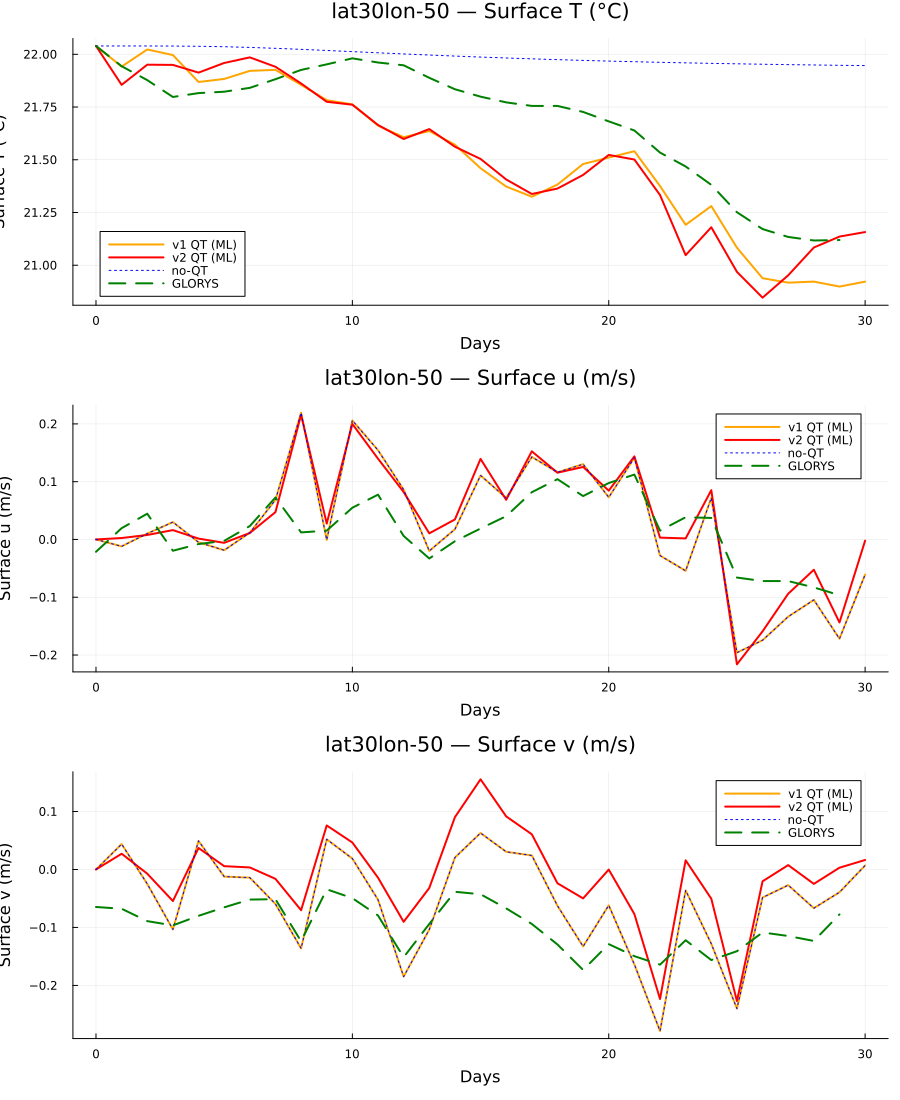

In [12]:
# Example: lat30/lon-50
plot_surface_evolution("lat30lon-50")

## final day profiles

In [13]:
function plot_final_profiles(site::String)
    d = load_site(site)
    vert_res = 16
    z = collect(range(0, stop=100, length=vert_res))

    sim_last_day_v2 = d[:v2_qt] !== nothing ?
        Int(round(d[:v2_qt]["saved_times"][end] / 86400)) : 30
    glorys_idx = min(sim_last_day_v2, d[:glorys] === nothing ? 30 : length(d[:glorys]["T_profiles"]))

    plots = Plots.Plot[]
    for (label, key) in [("T (°C)", "T_profiles"),
                           ("u (m/s)", "u_profiles"),
                           ("v (m/s)", "v_profiles"),
                           ("S (psu)", "S_profiles")]
        p = plot(xlabel=label, ylabel="Depth (m)", title="$site — day $sim_last_day_v2", yflip=true)

        if d[:v1_qt] !== nothing
            plot!(p, reverse(d[:v1_qt][key][end]), z, label="v1 QT", color=:orange)
        end
        if d[:v2_qt] !== nothing
            plot!(p, reverse(d[:v2_qt][key][end]), z, label="v2 QT", color=:red)
        end
        if d[:v1_noqt] !== nothing
            plot!(p, reverse(d[:v1_noqt][key][end]), z, label="no-QT", color=:blue, linestyle=:dot)
        end
        if d[:glorys] !== nothing
            plot!(p, d[:glorys][key][glorys_idx], z, label="GLORYS", color=:green, linestyle=:dash)
        end

        push!(plots, p)
    end

    return plot(plots..., layout=(2, 2), size=(1100, 800))
end

plot_final_profiles (generic function with 1 method)

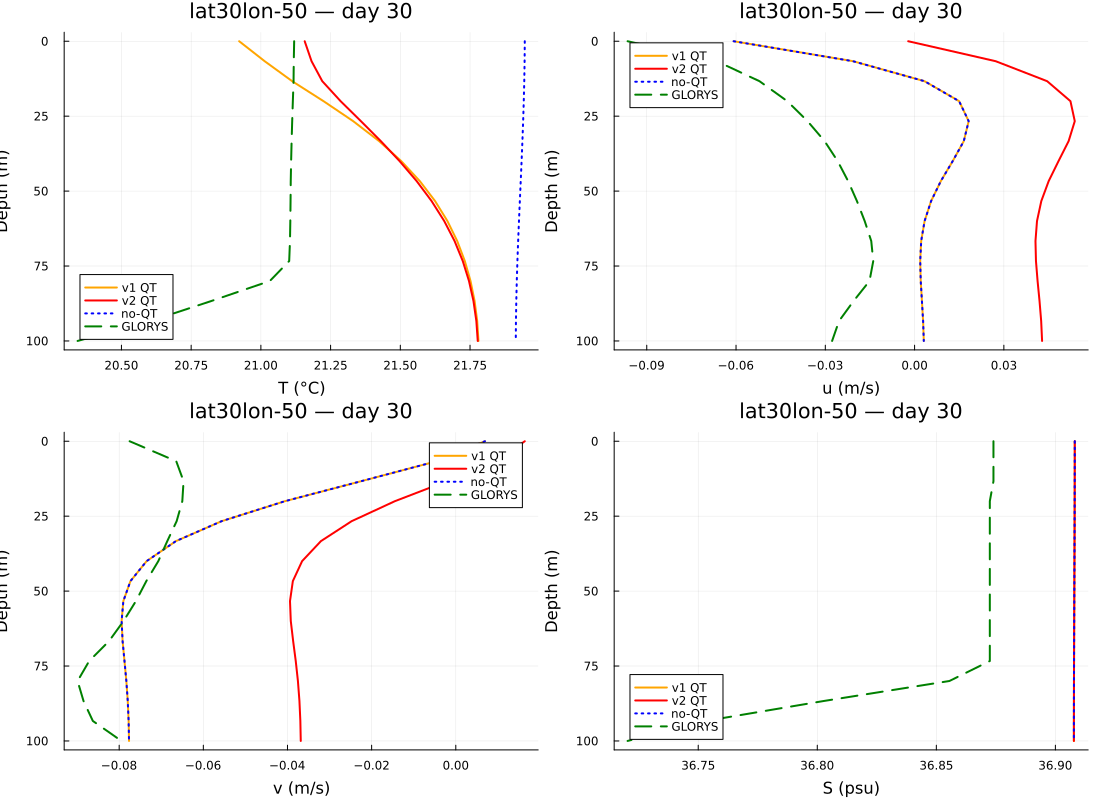

In [14]:
plot_final_profiles("lat30lon-50")

## day 30 summary

In [15]:
using Printf

println(rpad("site",14), " | ", rpad("T: v1  v2  GLY", 22), " | ",
        rpad("u: v1  v2  GLY", 24), " | ", rpad("v: v1  v2  GLY", 24))
println("-"^95)

for site in SITES
    d = load_site(site)
    function surf(src, key, sim=true)
        src === nothing && return NaN
        prof = sim ? src[key][end] : src[key][30]
        sim ? prof[end] : prof[1]
    end

    T1 = surf(d[:v1_qt], "T_profiles"); T2 = surf(d[:v2_qt], "T_profiles"); Tg = surf(d[:glorys], "T_profiles", false)
    u1 = surf(d[:v1_qt], "u_profiles"); u2 = surf(d[:v2_qt], "u_profiles"); ug = surf(d[:glorys], "u_profiles", false)
    v1s = surf(d[:v1_qt], "v_profiles"); v2s = surf(d[:v2_qt], "v_profiles"); vg = surf(d[:glorys], "v_profiles", false)

    @printf("%-14s | %5.2f %5.2f %5.2f | %6.3f %6.3f %6.3f | %6.3f %6.3f %6.3f\n",
            site, T1, T2, Tg, u1, u2, ug, v1s, v2s, vg)
end

site           | T: v1  v2  GLY         | u: v1  v2  GLY           | v: v1  v2  GLY          
-----------------------------------------------------------------------------------------------
lat30lon-50    | 20.92 21.16 21.12 | -0.061 -0.002 -0.096 |  0.007  0.016 -0.078
lat-25lon-10   | 22.93 22.69 23.83 |  0.060  0.015 -0.156 | -0.072 -0.018 -0.123
lat-45lon80    | 12.75 12.89 13.83 |  0.180  0.156  0.037 | -0.011 -0.021 -0.590
lat0lon-140    | 25.95 26.32 24.66 | -2.235 -2.170 -0.170 |  0.468  0.537 -0.343
lat30lon-150   | 21.75 21.81 20.36 | -0.037 -0.111 -0.104 |  0.015  0.034  0.010
lat40lon-25    | 15.25 15.37 16.48 | -0.105 -0.088 -0.117 |  0.093  0.104  0.082


## all 6 sites grid

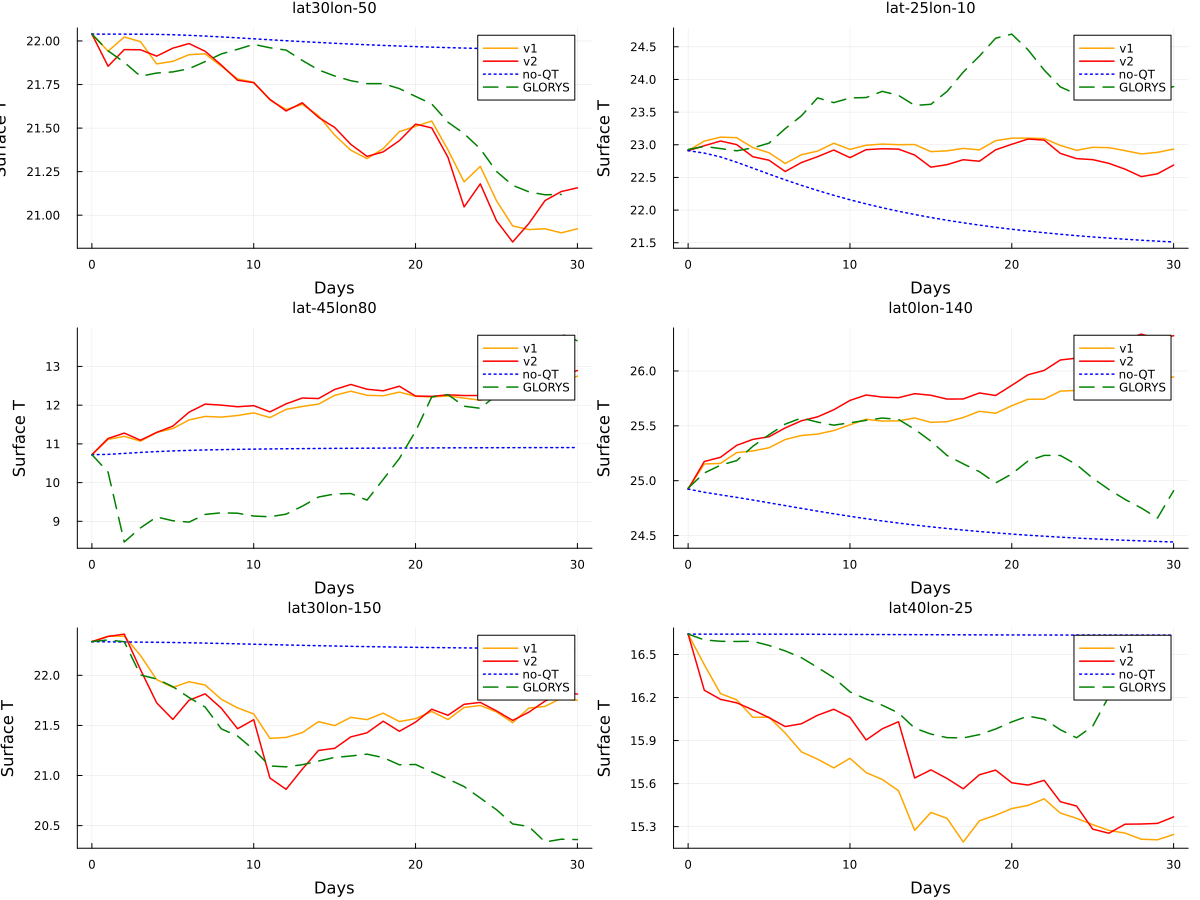

In [16]:
function tiny_T_plot(site)
    d = load_site(site)
    p = plot(xlabel="Days", ylabel="Surface T", title=site, legend=:topright, titlefontsize=10)
    for (src_key, label, color, ls) in [(:v1_qt,"v1",:orange,:solid),
                                          (:v2_qt,"v2",:red,:solid),
                                          (:v1_noqt,"no-QT",:blue,:dot)]
        if d[src_key] !== nothing
            t = d[src_key]["saved_times"] ./ 86400
            y = [p[end] for p in d[src_key]["T_profiles"]]
            plot!(p, t, y, label=label, color=color, linestyle=ls, linewidth=1.5)
        end
    end
    if d[:glorys] !== nothing
        y = [prof[1] for prof in d[:glorys]["T_profiles"][1:min(31, length(d[:glorys]["T_profiles"]))]]
        plot!(p, 0:length(y)-1, y, label="GLORYS", color=:green, linestyle=:dash, linewidth=1.5)
    end
    return p
end

plot([tiny_T_plot(s) for s in SITES]..., layout=(3,2), size=(1200, 900))